In [1]:
import pandas as pd
import xarray as xr
import numpy as np
from importlib import reload

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors     as mpcolors
import cartopy.crs as ccrs

import mod_plotting as mod_plot
import mod_regression as mod_reg
import figs_pcm


import figs_datadistributions as figs_dd

In [4]:
import mod_loading as loader

In [ ]:
# folder = '../working-vars/regression/trainval-splits/'

# trainDF = pd.read_csv(folder + 'trainDF_allplat_floatparam_pHbias5_pK1_pc8_gmm8_excludeClass3_acc20260126.csv', index_col=0)
# valDF = pd.read_csv(folder + 'valDF_allplat_floatparam_pHbias5_pK1_pc8_gmm8_excludeClass3_acc20260126.csv', index_col=0)

In [ ]:
folder = '../working-vars/regression/trainval-splits/'

# trainDF = pd.read_csv(folder + 'trainDF_allplat_pc8_gmm6_excludeClasses4_pHbias5_pK1_acc20260122.csv', index_col=0)
# valDF = pd.read_csv(folder + 'valDF_allplat_pc8_gmm6_excludeClasses4_pHbias5_pK1_acc20260122.csv', index_col=0)

trainDF = pd.read_csv(folder +  'trainDF_allplat_floatparam_pHbias5_pK1_pc8_gmm7_excludeClass4_acc20260205.csv', index_col=0)
valDF = pd.read_csv(folder +  'valDF_allplat_floatparam_pHbias5_pK1_pc8_gmm7_excludeClass4_acc20260205.csv', index_col=0)


allDF = pd.concat([trainDF, valDF], axis=0)
allClasses = {k:df for k,df in allDF.groupby('cluster')}
trainClasses = {k:df for k,df in trainDF.groupby('cluster')}
valClasses = {k:df for k,df in valDF.groupby('cluster')}

In [22]:
allDF = pd.concat([trainDF, valDF], axis=0)
allClasses = {k:df for k,df in allDF.groupby('cluster')}
trainClasses = {k:df for k,df in trainDF.groupby('cluster')}
valClasses = {k:df for k,df in valDF.groupby('cluster')}

mod_reg.get_trainval_counts(trainClasses, valClasses, n_gmm=6)

,train,validation,train_float,train_ship,val_float,val_ship,train_pc_float,val_pc_float,TOTAL_FLOAT,TOTAL_SHIP,TOTAL_OBS
cluster,,,,,,,,,,,
1,2161,218,573,1588,153,65,26.515502,70.183486,726,1653,2379
2,2648,545,1981,667,365,180,74.811178,66.972477,2346,847,3193
3,1496,447,1266,230,336,111,84.625668,75.167785,1602,341,1943
4,464,73,308,156,35,38,66.379310,47.945205,343,194,537
5,1977,687,1527,450,618,69,77.238240,89.956332,2145,519,2664
6,1569,503,511,1058,222,281,32.568515,44.135189,733,1339,2072


In [ ]:
[bgcArgo_trainval, bgcArgo_test, 
        socat_trainval, coreArgo_application] = loader.import_p2_clustered(type = 'class-gapfilled', pcm_params='pc8_gmm6')

[trainvalDF, coreDF, testDF] = loader.import_p3_trainval(pcm_desc = 'pc8_gmm6_excludeClass5')

Importing processed Dataframes with gap-filled classes; pc8_gmm6...
Returned [bgcArgo_trainval(2014-2023), bgcArgo_test(2024), socat_trainval(2014-2023), coreArgo_application(2014-2023)]


In [ ]:
valClasses = {k:df for k,df in trainvalDF.groupby('cluster')}


In [14]:
trainvalDF_all = pd.read_csv('../working-vars/regression/P3-trainval/P3-trainval_bgcArgo_SOCAT_2014-2023_floatparam_pHbias5_pK1_pc8_gmm6_excludeClass5_acc20260211.csv')

In [79]:

[trainvalDF, coreDF, testDF] = loader.import_p3_trainval(pcm_desc = 'pc8_gmm6_excludeClass5')

12813 profiles in trainvalDF_all (2014-2023);  270177 profiles in coreDF (2014-2023)
1807 profiles in testDF (2024 bgcArgo)


In [ ]:

# def map_platformDF(platDF, ax=None, figsize=(9,9), dotsize=0.5, markerscale=8, dotalpha=0.5, dotcolor='r', label=''):

#     fig = plt.figure(figsize=figsize, layout='constrained')
#     ax = plt.subplot(projection=ccrs.SouthPolarStereo())

#     format_southpolar(ax)

#     ax.scatter(platDF.longitude, platDF.latitude, alpha=dotalpha, s=dotsize, 
#                 transform=ccrs.PlateCarree(), zorder=20,
#                 label=(label), c=dotcolor)

#     ax.add_patch(fronts_patch('sie')) #sie

#     ax.legend(loc='upper right', markerscale=markerscale)

#     return ax

In [7]:
import mod_southpolarplot as sopo

In [80]:
trainvalDF_all.columns
# plot_classes = {k:df for k, df in plot_data.groupby('cluster')}

Index(['Unnamed: 0', 'wmoid', 'prof_datetag', 'datetime', 'latitude',
       'longitude', 'ydcos', 'ydsin', 'CT', 'SA', 'sst', 'sss', 'mld', 'adt',
       'atmos_pres_Pa', 'atmos_pres_atm', 'vapor_pres_atm', 'pCO2_standard',
       'pCO2_pHbias3', 'pCO2_pHbias5', 'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1',
       'pco2_atmos', 'pco2_ocean', 'delta_pco2', 'class_assign', 'platform',
       'cluster1_prob', 'cluster2_prob', 'cluster3_prob', 'cluster4_prob',
       'cluster5_prob', 'cluster', 'cruiseid', 'linear_time', 'nearest_profid',
       'prof_datetime', 'prof_lat', 'prof_lon', 'yd_sep', 'km_sep', 'fco2rec'],
      dtype='object')

In [29]:


plat_colors = {'bgc': "crimson", 
               'socat' : "#345DF1", 
               'core' : "#EBD367", 
               'train' : "#332288", 
                   'val' :  "#88CCEE", 
                   'combined' : "#524F4F",
                   'train_comb':  "#332288", 
                   'val_comb':  "#88CCEE", 
                   'train_float': "#882255",  # rose
                   'val_float': "#DDCC77",  # rose
                   'train_ship': "#44AA99",  # dark blue
                   'val_ship': "#CC6677",  # dark blue
                   }


TypeError: mean() got an unexpected keyword argument 'dim'

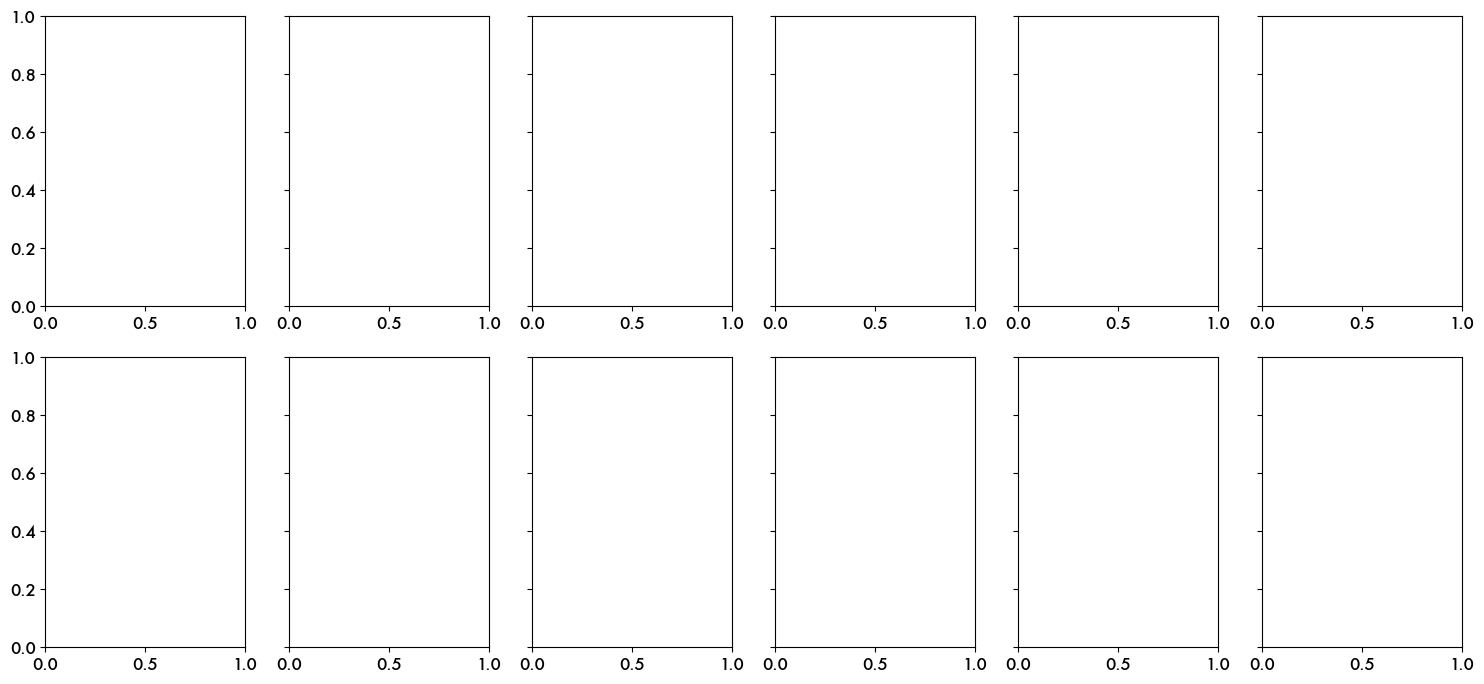

In [124]:
class_data = {k:df for k, df in coreDF.groupby('cluster')}
figs_pcm.mean_tracer_profiles_paneled(class_data)

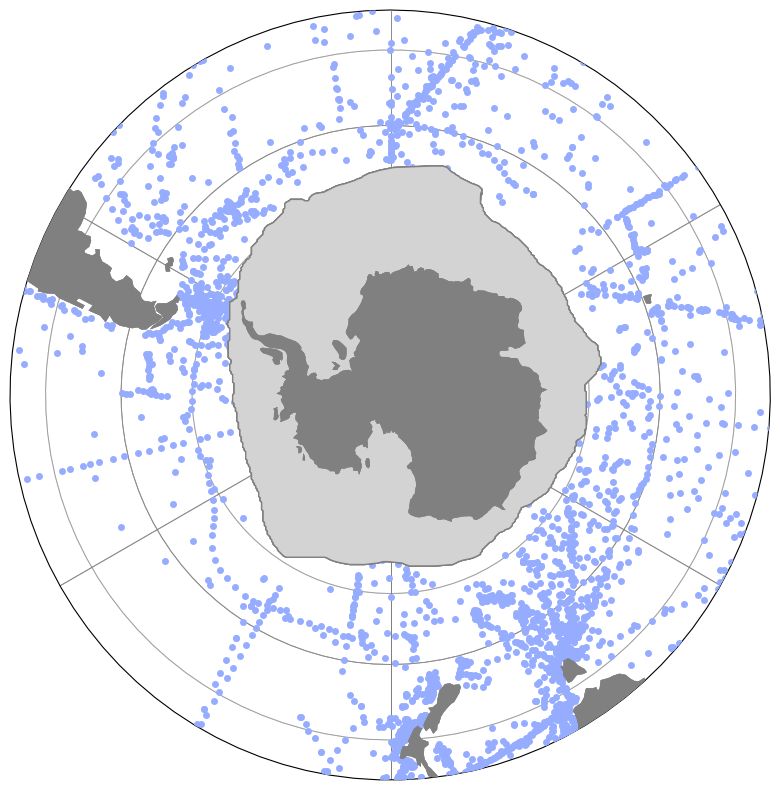

In [151]:
plt.rcParams.update(mod_plot.my_params(16))


fig = plt.figure(figsize=(10,10))
ax = plt.subplot(projection=ccrs.SouthPolarStereo())

sopo.format_southpolar(ax, map_facecolor='lightgray',
                       land_facecolor='gray')


plot_data = trainvalDF[~trainvalDF.cruiseid.isna()].copy()
sopo.map_platformDF(plot_data, ax=ax, figsize=(9,9), dotsize=16, markerscale=3, dotalpha=1, dotcolor=figs_dd.plat_colors['socat'], label='')


sopo.add_frontlines(ax, types=['sie']) 

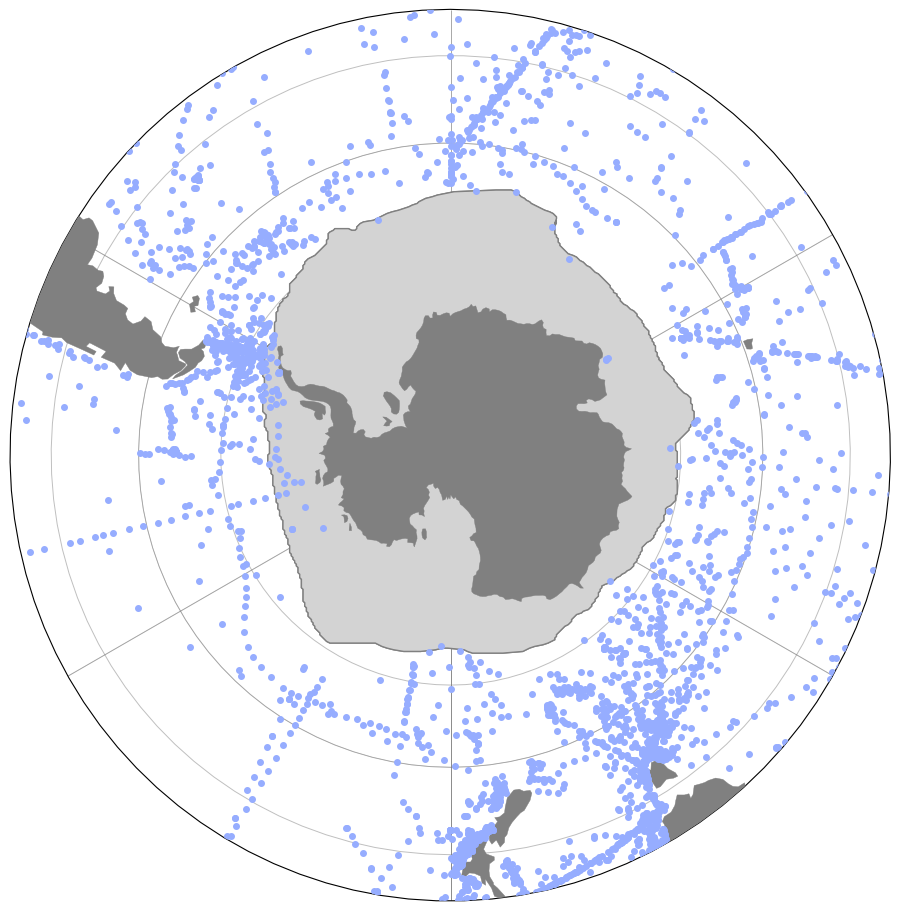

In [146]:
# plot_data = trainvalDF.copy()
# sopo.map_platformDF(plot_data, ax=None, figsize=(5,5), dotsize=16, markerscale=8, dotalpha=0.7, dotcolor='crimson')


plot_data = trainvalDF[~trainvalDF.cruiseid.isna()].copy()
ax = sopo.map_platformDF(plot_data, ax=None, figsize=(9,9), dotsize=16, markerscale=3, dotalpha=1, dotcolor=figs_dd.plat_colors['socat'], label='')

# plot_data = trainvalDF[~trainvalDF.wmoid.isna()].copy()
# sopo.map_platformDF(plot_data, ax=ax, figsize=(9,9), dotsize=16, markerscale=3, dotalpha=0.7, dotcolor=figs_dd.plat_colors['bgc'], label='BGC-Argo')


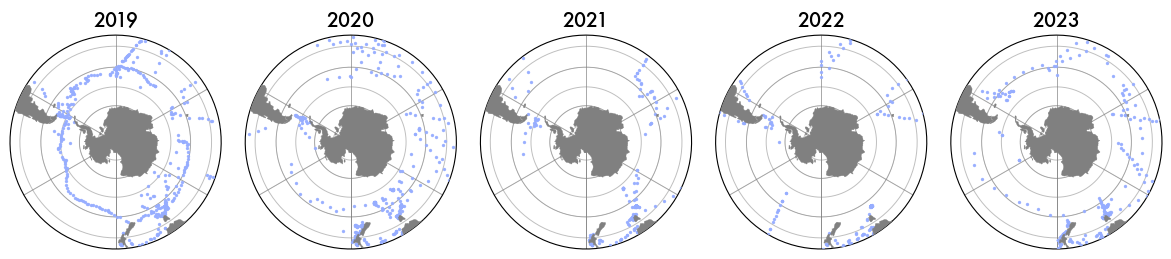

In [69]:
# FOR SOCAT, originally from 0.5_
# SOCAT obs by year
import mod_ocean 

temp = mod_ocean.expand_datetime(trainvalDF[~trainvalDF.cruiseid.isna()].copy(), type='dataframe')
templabel = 'socat'

# temp = mod_ocean.expand_datetime(trainvalDF[~trainvalDF.wmoid.isna()].copy(), type='dataframe')
# templabel = 'bgc'

# temp = mod_ocean.expand_datetime(coreDF, type='dataframe')
# templabel = 'core'


fig, axs = plt.subplots(1,5, figsize=(12,8), layout='tight', subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax in axs.flatten():
    sopo.format_southpolar(ax)

for ind, ax in enumerate(axs.flatten()):
    yr = ind + 2019
    data = temp[temp.year == yr]
    # data = temp.where(temp.year == yr)
    figtitle = str(yr)
    # print(len(data))
    ax.scatter(data.longitude, data.latitude, c=figs_dd.plat_colors[templabel], s=2, alpha=0.9, transform=ccrs.PlateCarree(), label=templabel, zorder=3)
    ax.set_title(figtitle)

# ax.legend()

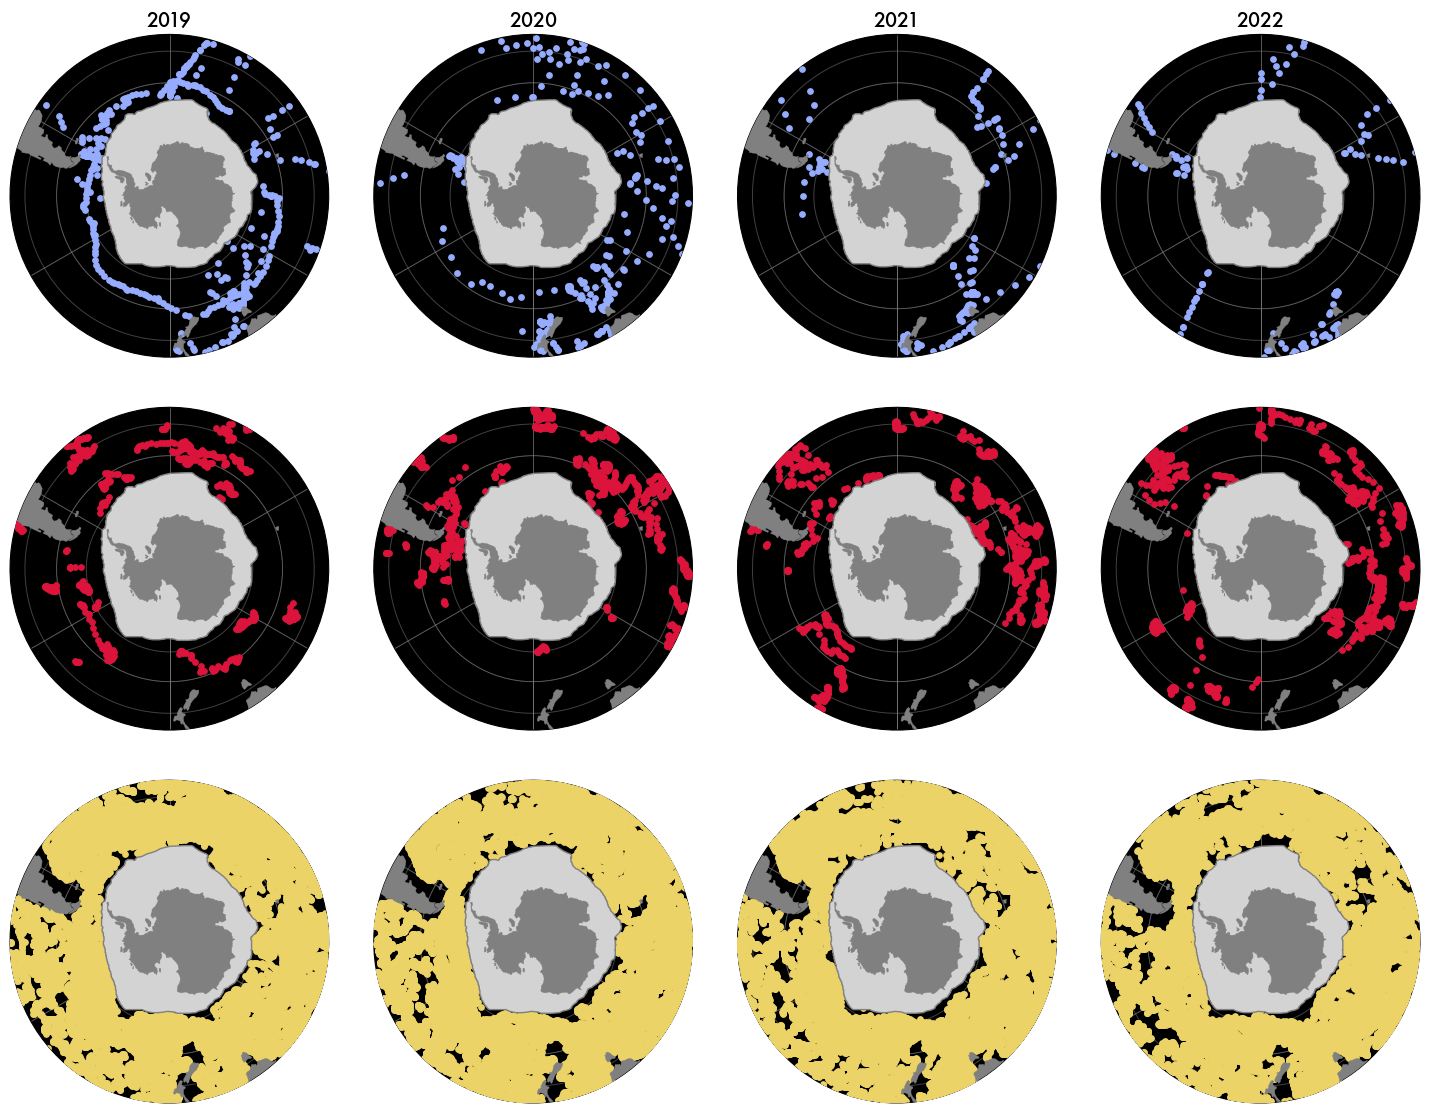

In [166]:
# FOR SOCAT, originally from 0.5_
# SOCAT obs by year
import mod_ocean 

temp = mod_ocean.expand_datetime(trainvalDF[~trainvalDF.cruiseid.isna()].copy(), type='dataframe')
templabel = 'socat'

# temp = mod_ocean.expand_datetime(trainvalDF[~trainvalDF.wmoid.isna()].copy(), type='dataframe')
# templabel = 'bgc'

# temp = mod_ocean.expand_datetime(coreDF, type='dataframe')
# templabel = 'core'

plt.rcParams.update(mod_plot.my_params(30))

fig, axs = plt.subplots(3,4, figsize=(15,12), layout='tight', subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax in axs.flatten():
    sopo.format_southpolar(ax)

for ind, ax in enumerate(axs[0,:]):
    yr = ind + 2019

    temp = mod_ocean.expand_datetime(trainvalDF[~trainvalDF.cruiseid.isna()].copy(), type='dataframe')
    templabel = 'socat'
    data = temp[temp.year == yr]
    figtitle = str(yr)
    ax.scatter(data.longitude, data.latitude, c=figs_dd.plat_colors[templabel], s=15, alpha=1, transform=ccrs.PlateCarree(), label=templabel, zorder=3)
    ax.set_title(figtitle)

for ind, ax in enumerate(axs[1,:]):
    yr = ind + 2019

    temp = mod_ocean.expand_datetime(trainvalDF[~trainvalDF.wmoid.isna()].copy(), type='dataframe')
    templabel = 'bgc'

    data = temp[temp.year == yr]
    figtitle = str(yr)
    ax.scatter(data.longitude, data.latitude, c=figs_dd.plat_colors[templabel], s=15, alpha=1, transform=ccrs.PlateCarree(), label=templabel, zorder=3)
    # ax.set_title(figtitle)

for ind, ax in enumerate(axs[2,:]):
    yr = ind + 2019

    temp = mod_ocean.expand_datetime(coreDF, type='dataframe')
    templabel = 'core'
    data = temp[temp.year == yr]
    figtitle = str(yr)
    ax.scatter(data.longitude, data.latitude, c=figs_dd.plat_colors[templabel], s=15, alpha=1, transform=ccrs.PlateCarree(), label=templabel, zorder=3)
    # ax.set_title(figtitle)


for ax in axs.flatten():
    ax.set_facecolor('k')
    



# ax.legend()

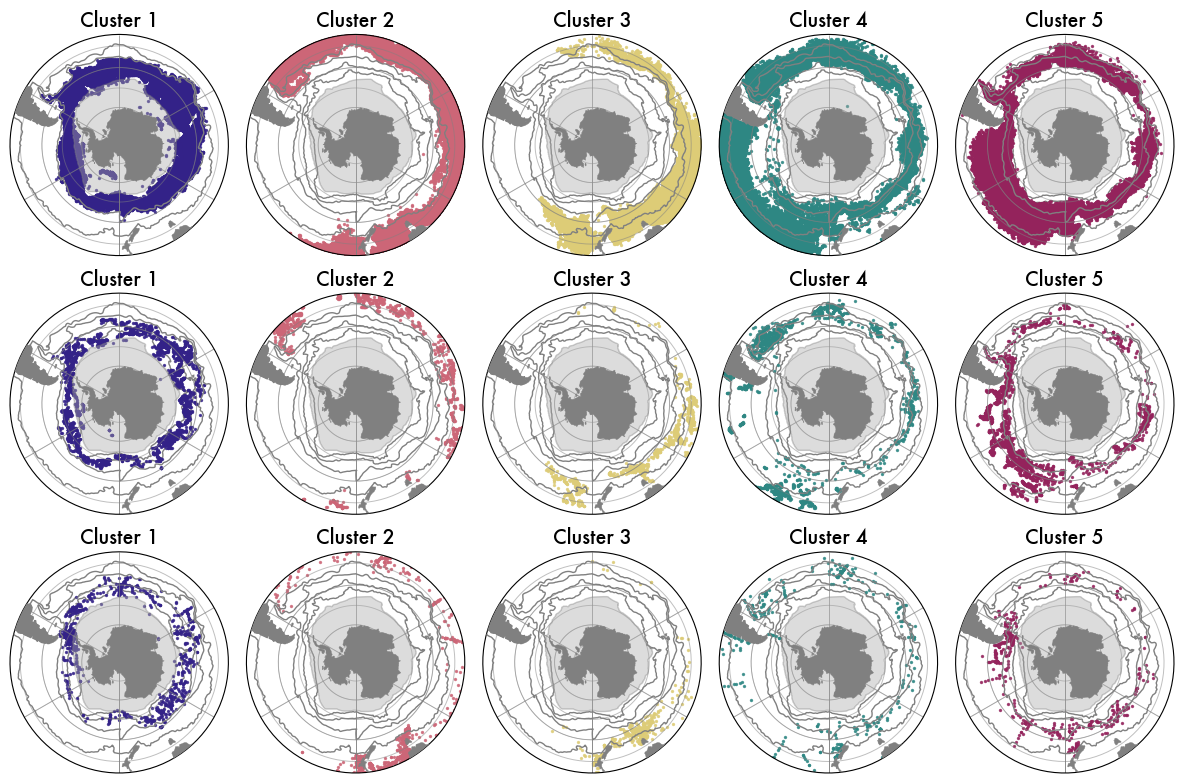

In [ ]:
fig, axs = plt.subplots(3,5, figsize=(12,8), layout='tight', subplot_kw={'projection': ccrs.SouthPolarStereo()})

figs_pcm.sopolar_classes_paneled(core_locs, axs = axs[0,:], numpanels=[1,n_clusters]);
figs_pcm.sopolar_classes_paneled(bgc_locs, axs = axs[1,:], numpanels=[1,n_clusters]);
figs_pcm.sopolar_classes_paneled(socat_locs, axs = axs[2,:], numpanels=[1,n_clusters]);

<GeoAxes: title={'center': 'Class 6'}>

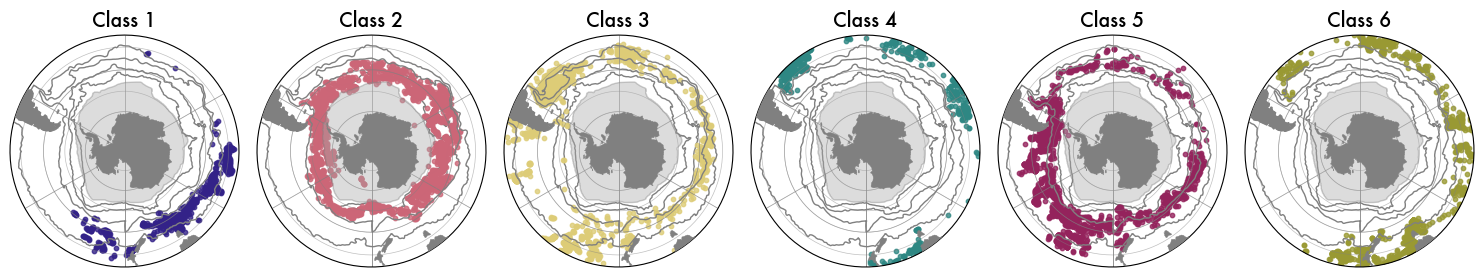

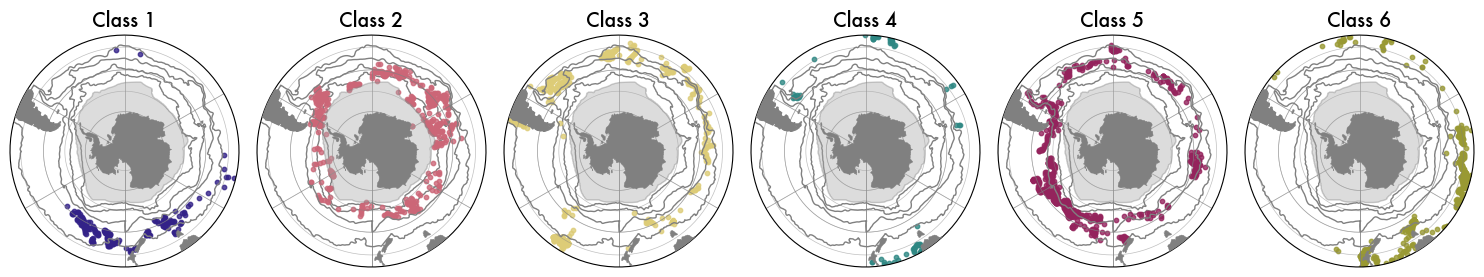

In [ ]:


import figs_pcm

figs_pcm.sopolar_classes_paneled(trainClasses, numpanels=[1,6],dotsize=10)
figs_pcm.sopolar_classes_paneled(valClasses, numpanels=[1,6],dotsize=10)


In [ ]:

# traindict = {'combined': trainDF,
#              'float' : trainDF[~trainDF.wmoid.isna()],
#              'ship': trainDF[~trainDF.cruiseid.isna()]}
# valdict = {'combined': valDF,
#             'float' : valDF[~valDF.wmoid.isna()],
#             'ship': valDF[~valDF.cruiseid.isna()]}

# combdict = {'train_comb' : trainDF,
#             'val_comb' : valDF}
# floatdict = {'train_float' : trainDF[~trainDF.wmoid.isna()],
#              'val_float' : valDF[~valDF.wmoid.isna()]}
# shipdict = {'train_ship' : trainDF[~trainDF.cruiseid.isna()],
#             'val_ship' : valDF[~valDF.cruiseid.isna()]}

# train_classes = {k:v for k, v in trainDF.groupby('cluster')}
# val_classes = {k:v for k, v in valDF.groupby('cluster')}



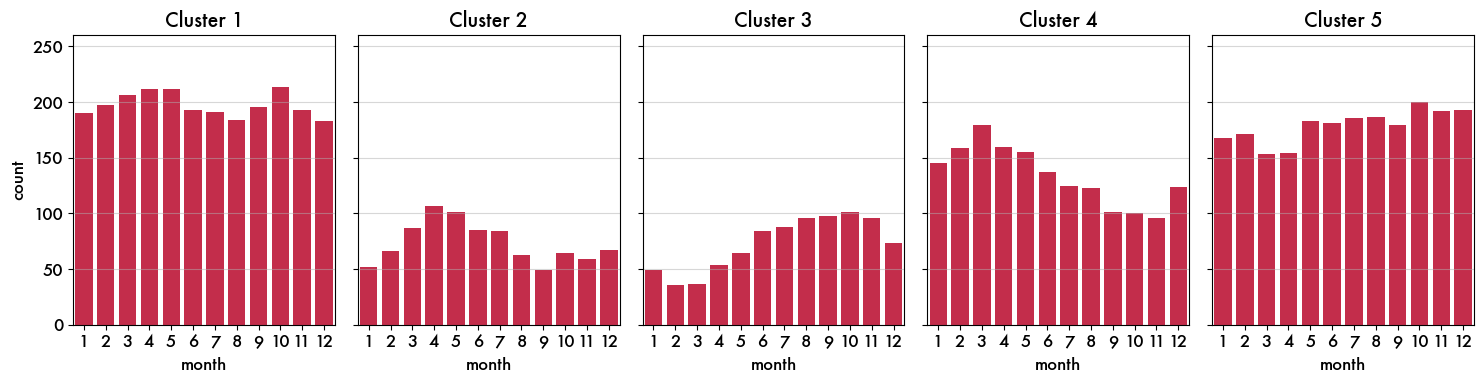

In [145]:
# figs_dd.countplot_months_byclass():
# ind_list = [x for x in storedRuns_gmm8_ex3[run_tag].ind_list]
# nclasses = len(ind_list)
import seaborn as sns

valClasses = {k:df for k,df in trainvalDF.groupby('cluster')}

fig, axs = plt.subplots(1,5, figsize=(15,4), layout='tight', sharey='row')
axs = axs.flatten()

for key, val in enumerate(valClasses.keys()):
    ax = axs[key]

    # # training
    # foo = myocn.expand_datetime(trainClasses[val], type='dataframe')
    # sns.countplot(x='month', data=foo, ax=ax, color = 'lightblue')
    
    # validation
    foo = mod_ocean.expand_datetime(valClasses[val], type='dataframe')

    # foo = foo[~foo.cruiseid.isna()]
    # sns.countplot(x='month', data=foo, ax=ax, color = "#96ADFF")
    # ax.set_ylim([0,260])

    foo = foo[~foo.wmoid.isna()]
    sns.countplot(x='month', data=foo, ax=ax, color = "crimson")
    ax.set_ylim([0,260])


    ax.grid(axis='y', alpha=0.5, zorder=1)
    ax.set_title('Cluster ' + str(val), fontsize=14)


In [25]:
trainDF.cluster.unique()

array([1, 2, 3, 4, 5, 6])

In [81]:
def dict_split_byClass(inputDF, restrict_platform = None):
    if restrict_platform == 'float':
        inputDF = inputDF[~inputDF.wmoid.isna()]
    elif restrict_platform == 'ship':
        inputDF = inputDF[~inputDF.cruiseid.isna()]

    # inputDF = mod_reg.separate_platforms[0]
    
    return {k:v for k, v in inputDF.groupby('cluster')}

def dict_split_byPlatform(inputDF, df_tag, restrict_platform = None, include_combined = True):
    if restrict_platform == 'float':
        inputDF = inputDF[~inputDF.wmoid.isna()]
    elif restrict_platform == 'ship':
        inputDF = inputDF[~inputDF.cruiseid.isna()]

    result = {}
    result[df_tag + '_float'] = inputDF[~inputDF.wmoid.isna()]
    result[df_tag + '_ship'] = inputDF[~inputDF.cruiseid.isna()]
    if include_combined: result[df_tag + '_comb'] = inputDF
    
    return result

def dict_split_trainval(trainDF, valDF, restrict_platform = ''):
    if restrict_platform == 'float':
        trainDF = trainDF[~trainDF.wmoid.isna()]
        valDF = valDF[~valDF.wmoid.isna()]
        restrict_platform = '_float'
    elif restrict_platform == 'ship':
        trainDF = trainDF[~trainDF.cruiseid.isna()]
        valDF = valDF[~valDF.cruiseid.isna()]
        restrict_platform = '_ship'

    result = {} ; 
    result['train' + restrict_platform] = trainDF
    result['val' + restrict_platform] = valDF
    return result


In [83]:
dict_split_byPlatform(trainvalDF, "train", include_combined=False)

{'train_float':          Unnamed: 0      wmoid      prof_datetag                    datetime  \
 0     5904396_id001  5904396.0  5904396_20140412  2014-04-12 03:17:59.999996   
 1     5904396_id004  5904396.0  5904396_20140428  2014-04-28 02:57:59.999997   
 2     5904396_id008  5904396.0  5904396_20140519  2014-05-19 15:33:00.000003   
 3     5904185_id011  5904185.0  5904185_20140720  2014-07-20 09:19:00.000002   
 4     5904185_id014  5904185.0  5904185_20140820  2014-08-20 07:04:00.000002   
 ...             ...        ...               ...                         ...   
 7877  5906562_id017  5906562.0  5906562_20230702  2023-07-02 18:45:00.000000   
 7878  5906562_id018  5906562.0  5906562_20230713  2023-07-13 01:44:59.999997   
 7879  5906562_id019  5906562.0  5906562_20230723  2023-07-23 09:16:00.000003   
 7880  5906567_id017  5906567.0  5906567_20230505  2023-05-05 18:17:59.999996   
 7881  5906567_id019  5906567.0  5906567_20230526  2023-05-26 06:59:59.999997   
 
       lati

In [176]:
plt.rcParams.update(mod_plot.my_params(30))

Text(0.5, 0, 'ΔpCO$_{2}$ (µatm)')

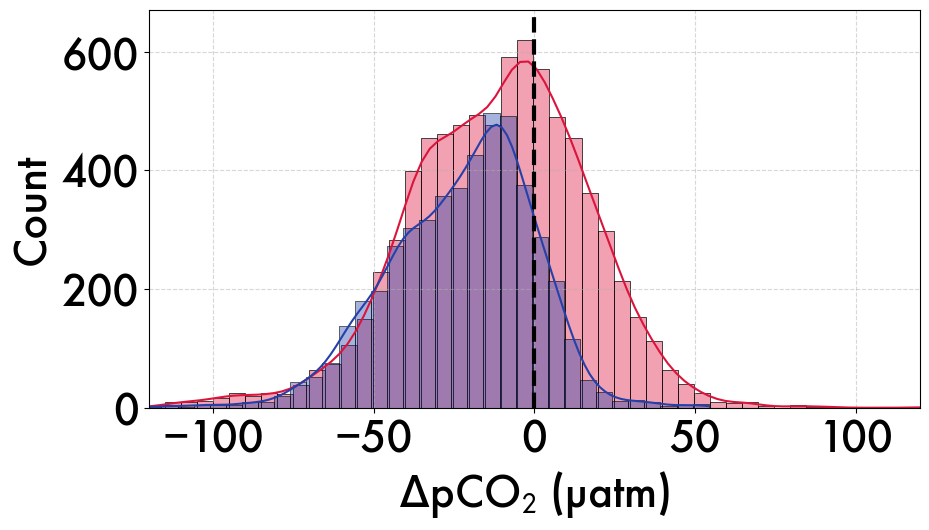

In [182]:
fig = plt.figure(figsize=(10,6), layout='tight')
ax = plt.gca()
figs_dd.overlay_histograms_singleVar(dict_split_byPlatform(trainvalDF, "trainval", include_combined=False), 'delta_pco2', 
                                     ax=ax, 
                                     binwidth=5, showLegend=False)

ax.set_xlim([-120,120])
ax.set_ylim([0, 670])
ax.vlines(x=0, ymin=0, ymax=670, colors='k', linestyles='dashed', alpha=1, zorder=30, linewidth=3)
ax.set_xlabel('ΔpCO$_{2}$ (µatm)') # delta pco2  

In [173]:
trainvalDF.columns

Index(['Unnamed: 0', 'wmoid', 'prof_datetag', 'datetime', 'latitude',
       'longitude', 'ydcos', 'ydsin', 'CT', 'SA', 'sst', 'sss', 'mld', 'adt',
       'atmos_pres_Pa', 'atmos_pres_atm', 'vapor_pres_atm', 'pCO2_standard',
       'pCO2_pHbias3', 'pCO2_pHbias5', 'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1',
       'pco2_atmos', 'pco2_ocean', 'delta_pco2', 'class_assign', 'platform',
       'cluster1_prob', 'cluster2_prob', 'cluster3_prob', 'cluster4_prob',
       'cluster5_prob', 'cluster', 'cruiseid', 'linear_time', 'nearest_profid',
       'prof_datetime', 'prof_lat', 'prof_lon', 'yd_sep', 'km_sep', 'fco2rec'],
      dtype='object')

Text(0.5, 0, 'Residual Δ-pCO$_{2}$ (µatm)')

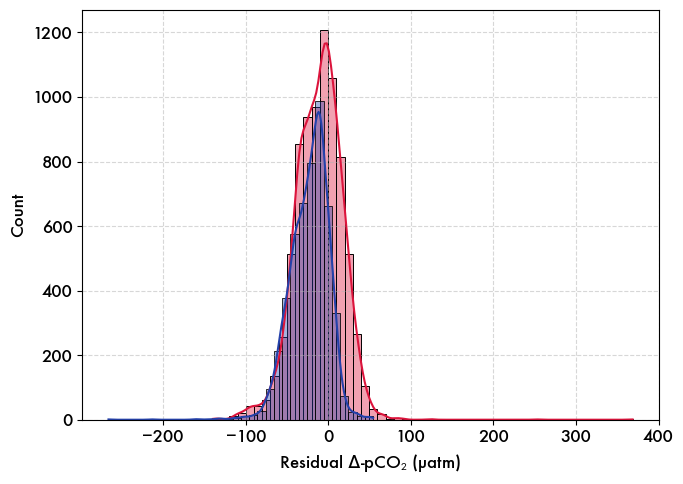

In [169]:
fig = plt.figure(figsize=(7,5), layout='tight')
ax = plt.gca()

# plot_data = {}
# plot_data['']
figs_dd.overlay_histograms_singleVar(dict_split_byPlatform(trainvalDF, "trainval", include_combined=False), 'delta_pco2', 
                                     ax=ax, 
                                     nbins=80, showLegend=False)

# ax.set_xlim([-120,100])
# ax.set_ylim([0, 0.025])
ax.vlines(x=0, ymin=0, ymax=.03, colors='k', linestyles='dashed', alpha=0.7, zorder=10)
ax.set_xlabel('Residual Δ-pCO$_{2}$ (µatm)') # delta pco2  

NameError: name 'trainDF' is not defined

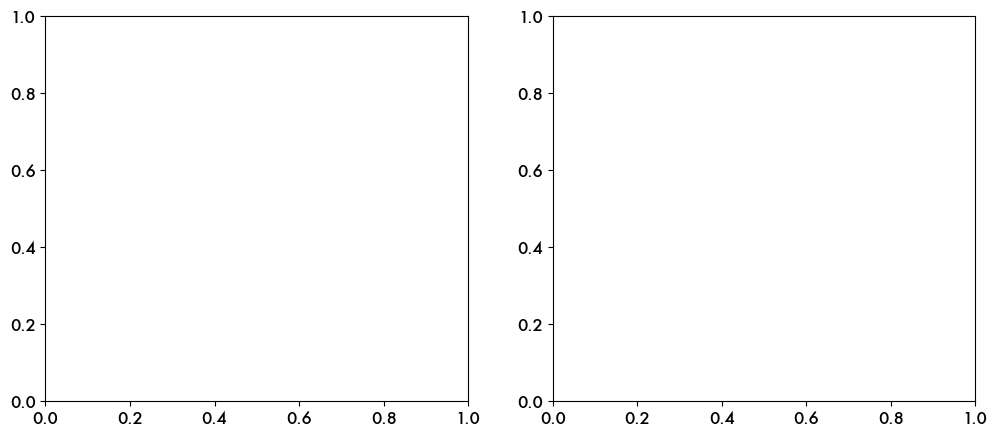

In [77]:
reload(figs_dd)

plotvar = 'delta_pco2'
sns.set_palette('Set2')
fig, axs = plt.subplots(1,2, figsize=(12,5), sharex=True)

for ax in axs[:1]:
    figs_dd.overlay_histograms_singleVar(dict_split_byPlatform(trainDF, "train", include_combined=False), plotvar, ax=ax, nbins=80)
    ax.set_title('Training data ' + plotvar)

for ax in axs[1:2]:
    figs_dd.overlay_histograms_singleVar(dict_split_byPlatform(valDF, "val", include_combined=False), plotvar, ax=ax, nbins=40)
    ax.set_title('Validation data ' + plotvar)

for ax in axs:
    ax.set_xlim([-130,90])
    ax.vlines(x=0, ymin=0, ymax=0.028, colors='r', linestyles='dashed')
    ax.set_ylim([0,0.028])

# ax.set_title('Training vs. Validation Data Distribution for ΔpCO2');

(array([ 118.,  164.,  254.,  331.,  386.,  541.,  694.,  682.,  922.,
        1084., 1129., 1131.,  863.,  712.,  419.,  275.,  272.,  134.,
         132.,   72.]),
 array([2.2645476 , 2.47705224, 2.68955688, 2.90206152, 3.11456616,
        3.3270708 , 3.53957544, 3.75208007, 3.96458471, 4.17708935,
        4.38959399, 4.60209863, 4.81460327, 5.02710791, 5.23961255,
        5.45211719, 5.66462182, 5.87712646, 6.0896311 , 6.30213574,
        6.51464038]),
 <BarContainer object of 20 artists>)

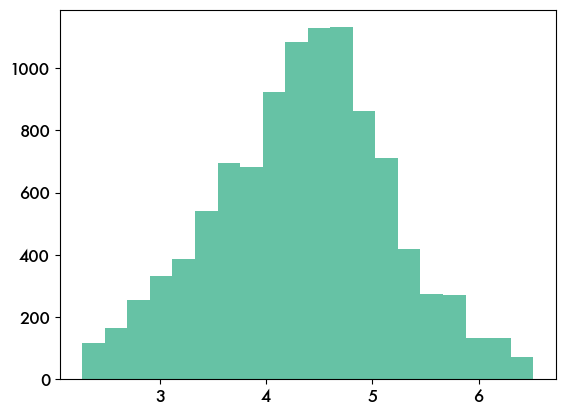

In [35]:
foo = np.log(trainDF.mld)
plt.hist(foo, bins=20)

Distributions between training and validation data


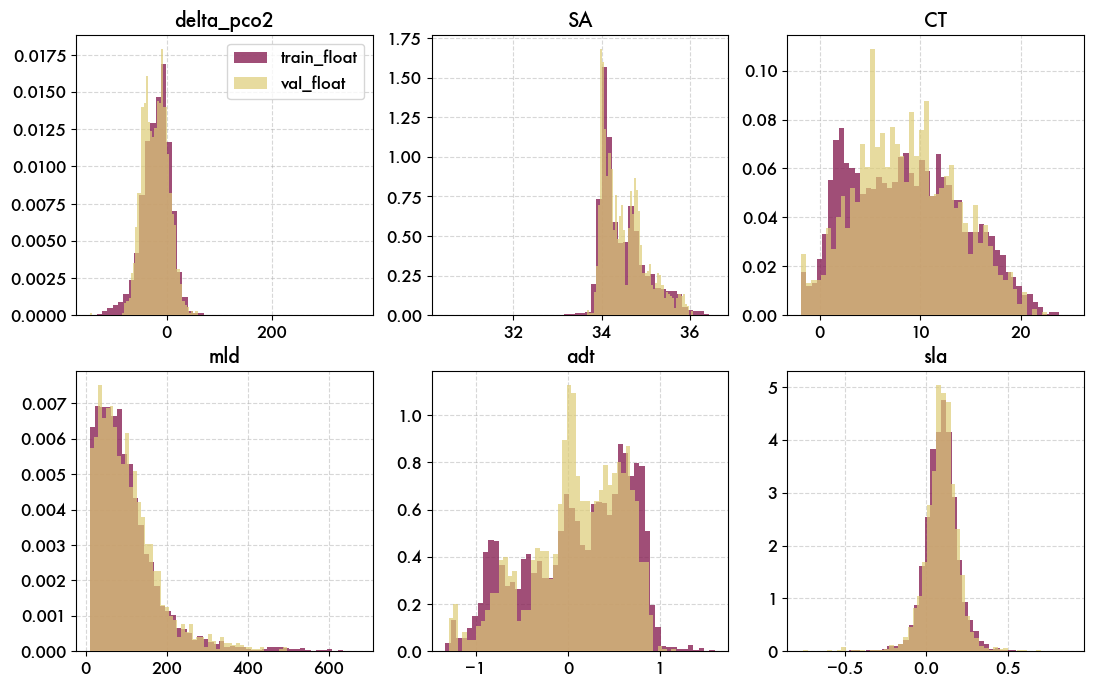

In [29]:
reload(figs_dd)
fig, axs = plt.subplots(2,3, figsize=(13,8))
axs = axs.flatten()

print('Distributions between training and validation data')

# choose_type = 'ship'
choose_type = 'float'
# choose_type = ''

# sns.set_palette('Dark2')
vars_to_plot = ['delta_pco2', 'SA', 'CT', 'mld', 'adt', 'sla']
for ind, val in enumerate(vars_to_plot):
    if ind == 0:
        figs_dd.overlay_histograms_singleVar(dict_split_trainval(trainDF, valDF, choose_type), val, nbins=50, alpha=0.8, ax=axs[ind], showLegend=True)
    else:
        figs_dd.overlay_histograms_singleVar(dict_split_trainval(trainDF, valDF, choose_type), val, nbins=50, alpha=0.8, ax=axs[ind], showLegend=False)
    axs[ind].set_title(val)



In [122]:
train_data_dict[5]

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,sampleid,cruiseid,nearest_profid,atm_pres_hPa,fco2rec,class1_prob,class2_prob,class3_prob,class4_prob,class5_prob
463,5904186_id002,5904186.0,5904186_20140419,5,2014-04-19 00:33:59.999999,-52.838,210.006,108.023611,-0.283529,0.958964,...,NaN,NaN,NaN,NaN,NaN,5.909668e-05,3.330870e-36,0.001513,1.214365e-07,0.998428
464,5904186_id003,5904186.0,5904186_20140424,5,2014-04-24 07:41:00.000001,-53.441,210.079,113.320139,-0.369606,0.929189,...,NaN,NaN,NaN,NaN,NaN,8.309411e-05,5.957735e-35,0.005842,4.859343e-07,0.994075
465,5904186_id004,5904186.0,5904186_20140429,5,2014-04-29 14:43:00.000000,-53.472,211.418,118.613194,-0.452564,0.891732,...,NaN,NaN,NaN,NaN,NaN,6.485218e-05,5.111608e-35,0.001102,9.649582e-08,0.998833
466,5904186_id005,5904186.0,5904186_20140505,5,2014-05-05 01:30:00.000000,-52.901,211.919,124.062500,-0.534046,0.845455,...,NaN,NaN,NaN,NaN,NaN,3.498120e-04,2.472713e-29,0.060141,1.639337e-06,0.939508
467,NaN,5904186.0,5904186_20140510,5,2014-05-10 07:54:00.000005,-52.794,211.804,129.329167,-0.608349,0.793670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10931,5906562_id015,5906562.0,5906562_20230612,5,2023-06-12 04:21:59.999998,-59.273,287.959,3449.181944,-0.937309,0.348500,...,NaN,NaN,NaN,NaN,NaN,8.953900e-08,4.319589e-04,0.001104,5.603808e-10,0.998463
10932,5906562_id016,5906562.0,5906562_20230622,5,2023-06-22 11:14:00.000004,-58.351,290.682,3459.468056,-0.984018,0.178070,...,NaN,NaN,NaN,NaN,NaN,5.827244e-09,2.444313e-04,0.008515,1.639674e-09,0.991240
10933,5906562_id017,5906562.0,5906562_20230702,5,2023-07-02 18:45:00.000000,-59.176,293.565,3469.781250,-0.999999,0.001613,...,NaN,NaN,NaN,NaN,NaN,1.531779e-06,2.766217e-02,0.018327,2.601104e-08,0.954009
10934,5906562_id018,5906562.0,5906562_20230713,5,2023-07-13 01:44:59.999997,-57.093,295.478,3480.072917,-0.984652,-0.174530,...,NaN,NaN,NaN,NaN,NaN,4.160851e-08,1.707406e-07,0.000619,3.237107e-10,0.999381


Distributions between float and ship data, split by class


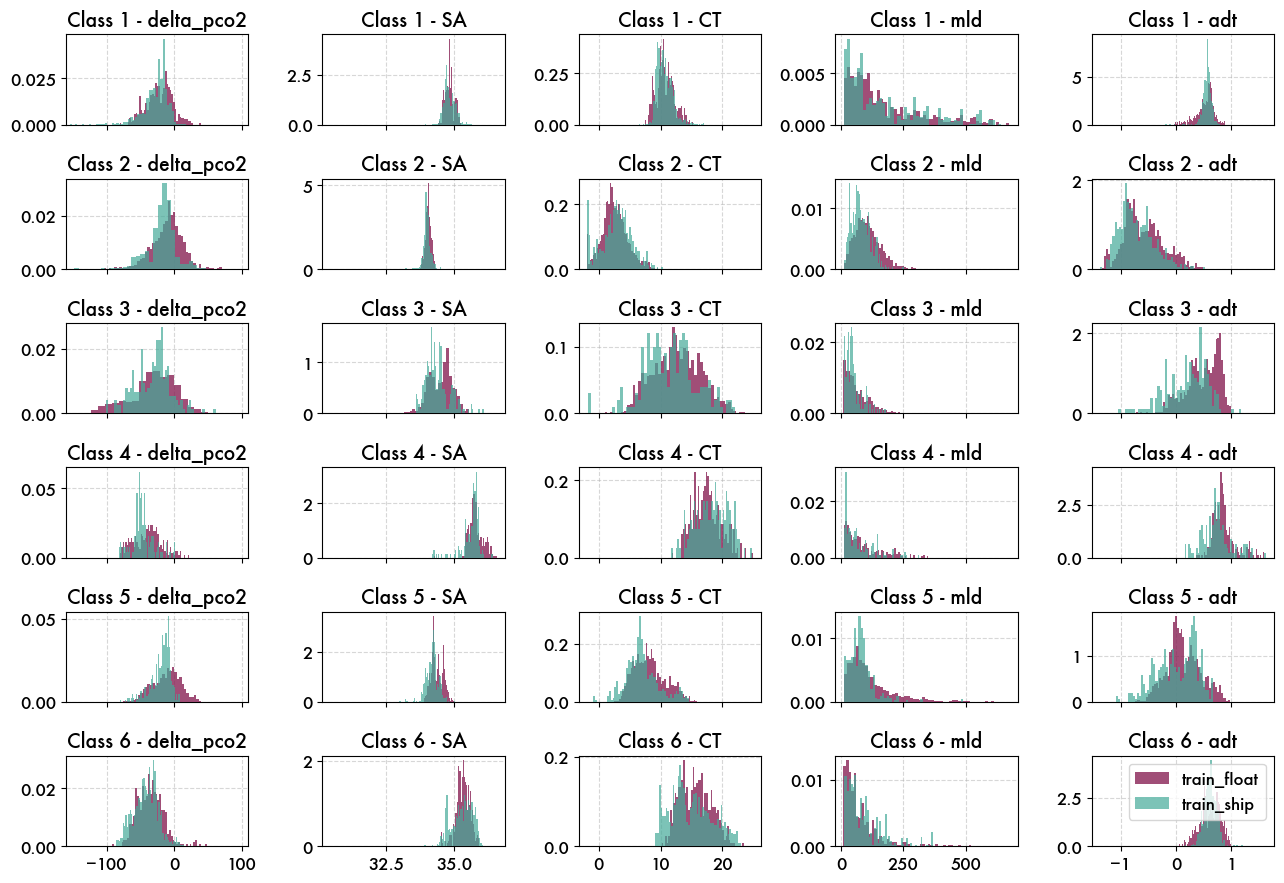

In [32]:
reload(figs_dd)
print('Distributions between float and ship data, split by class')

fig, axs = plt.subplots(6,5, figsize=(13,9), layout='tight', sharex='col')

n_clusters = trainDF.cluster.unique()
vars_to_plot = ['delta_pco2', 'SA', 'CT', 'mld', 'adt']
classes_dict = dict_split_byClass(trainDF)

for nclass in n_clusters:
    plot_data = dict_split_byPlatform(classes_dict[nclass], 'train', include_combined=False)

    for ind, plotvar in enumerate(vars_to_plot):
        ax = axs[nclass-1, ind]

        figs_dd.overlay_histograms_singleVar(plot_data, plotvar, nbins=50, alpha=0.8, ax=ax, showLegend=False)
        ax.set_title(f'Class {nclass} - ' + plotvar)
ax.legend()

for ax in axs[:,0]:
    ax.set_xlim([-160,110])
    # ax.vlines(x=0, ymin=0, ymax=0.028, colors='r', linestyles='dashed')

Distributions between train and val data, split by class


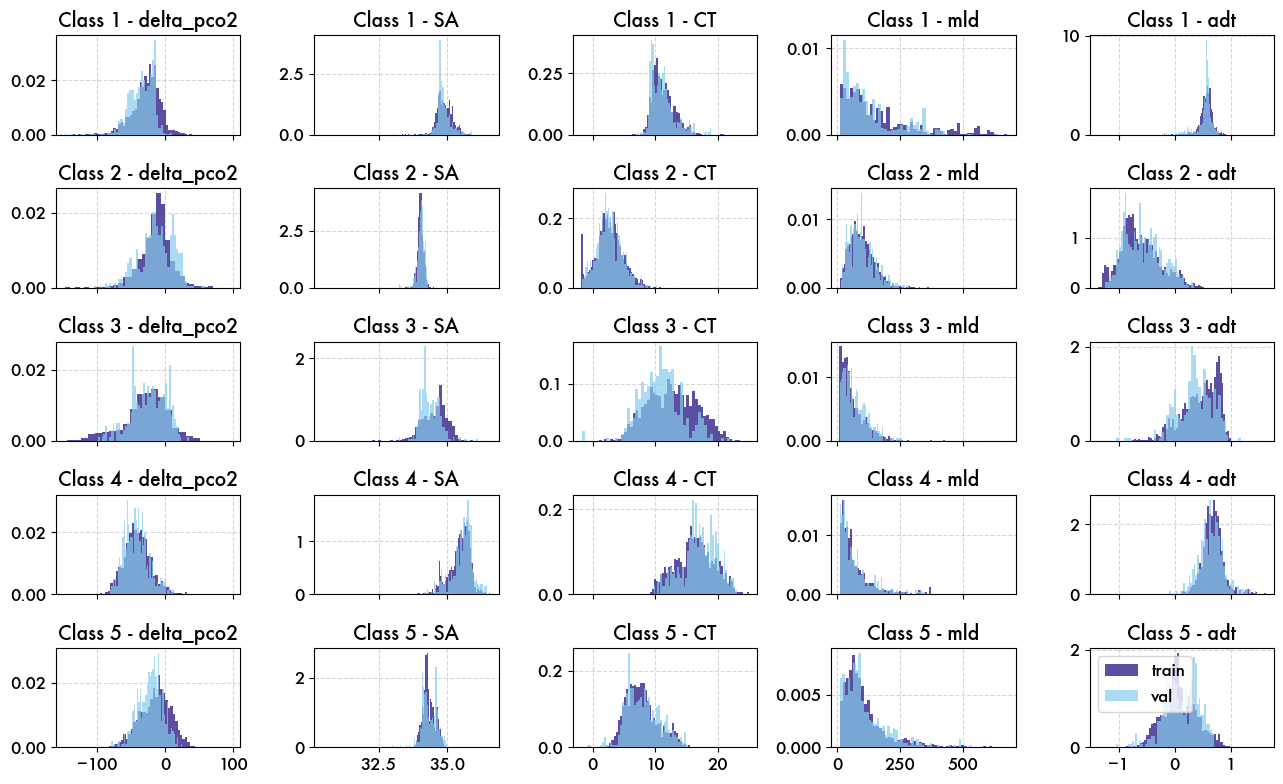

In [13]:
reload(figs_dd)
print('Distributions between train and val data, split by class')

fig, axs = plt.subplots(5,5, figsize=(13,8), layout='tight', sharex='col')

n_clusters = trainDF.cluster.unique()
vars_to_plot = ['delta_pco2', 'SA', 'CT', 'mld', 'adt']
train_classes_dict = dict_split_byClass(trainDF)
val_classes_dict = dict_split_byClass(valDF)

for nclass in n_clusters:
    plot_data = dict_split_trainval(train_classes_dict[nclass], val_classes_dict[nclass], restrict_platform='')

    for ind, plotvar in enumerate(vars_to_plot):
        ax = axs[nclass-1, ind]
        figs_dd.overlay_histograms_singleVar(plot_data, plotvar, nbins=50, alpha=0.8, ax=ax, showLegend=False)
        ax.set_title(f'Class {nclass} - ' + plotvar)


ax.legend()

for ax in axs[:,0]:
    ax.set_xlim([-160,110])

In [ ]:
print('Distributions between training and validation data, split by class')

In [ ]:
# # os tools
# import sys
# import os
# import os.path
# import requests
# import time
# import urllib3
# import shutil
# from tqdm import tqdm

# # data tools
# import numpy                 as np
# import pandas                as pd
# import xarray                as xr
# from   datetime              import date, datetime, timedelta                 # for saving figures with today's date
# import datetime
# import scipy
# from   scipy.stats           import kruskal              # for boxenplot stats
# from   scipy.stats           import mannwhitneyu         # for split violin plot stats
# import gsw


# # for all plots
# import matplotlib
# import matplotlib.pyplot     as plt                      # needed to make map setup
# import matplotlib.colors     as colors
# from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
# from   cmocean               import cm as cmo
# import seaborn               as     sns

# # for map
# import shapefile
# import cartopy                                           # to make map
# import matplotlib.path       as     mpath                # to draw circle for map
# import cartopy.crs           as     ccrs                 # for map projection
# import cartopy.feature       as     cfeature             # to add land features to map
# # from   xhistogram.xarray     import histogram            # for map histogram
# # from   mycolorpy             import colorlist as mcp     # to get n colors list
# import pyproj  
# import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
# from   osgeo                 import gdal
# # import scikit_posthocs       as     sp                   # for stats


# xr.set_options(display_expand_attrs = False)

In [ ]:
# Custom modules
import mod_cremas as crx 
import mod_ocean as myocn
import mod_argo 

from importlib import reload
import mod_plotting as myplt

plt.rcParams.update(myplt.my_params(size=12))

import shapefile
so_fronts = shapefile.Reader('./shapefiles/fronts/so_fronts.shp') 
stf_mod   = shapefile.Reader('./shapefiles/fronts/stf_mod/stf_mod.shp')

stf  = stf_mod.shape(0).points
saf  = so_fronts.shape(1).points
pf   = so_fronts.shape(2).points
sacc = so_fronts.shape(3).points
sie  = so_fronts.shape(4).points

max_latitude:          float = -30
add_gridlines:         bool  = True
color_land:            bool  = False
land_edgecolor:        str   = 'grey'
land_facecolor:        str   = 'grey'
fontsize:              float = 10
map_facecolor:         str   = 'white'
coast_linewidth:       float = 0.3
gridlines_linewidth:   float = 0.5
girdlines_color:       str   = 'grey'
gridlines_alpha:       float = 0.5
longitude_label_color: str   = 'grey'
latitude_label_color:  str   = 'grey'



In [ ]:
bgc2014_qc = pd.read_csv('/Volumes/cremas-repo/data/bgc/L1-qc/bgc_qcflags1258_yr2014_acc20250220.csv', index_col=0)
bgc2014_qc

,profid,pressure,wmoid,latitude,longitude,datetime,yearday,CT,SA,sigma0,...,salinity_qc,pressure_qc,time_qc,position_qc,temp_error,psal_error,pres_error,pH,pH_qc,pH_error
5538312,5904184_id001,7.550000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062752,33.916040,27.101326,...,8,1,1,1,0.002,0.01,2.4,8.036440,1,0.015321
5538315,5904184_id001,11.730000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062162,33.915951,27.101285,...,8,1,1,1,0.002,0.01,2.4,8.037667,1,0.015321
5538319,5904184_id001,16.220001,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062796,33.915852,27.101172,...,8,1,1,1,0.002,0.01,2.4,8.038201,1,0.015321
5538322,5904184_id001,21.660000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.064599,33.915659,27.100925,...,8,1,1,1,0.002,0.01,2.4,8.038585,1,0.015321
5538326,5904184_id001,26.610000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.063223,33.915310,27.100716,...,8,1,1,1,0.002,0.01,2.4,8.039553,1,0.015321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6338291,5904478_id002,1798.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.035283,34.836521,27.841434,...,1,1,1,1,0.002,0.01,2.4,7.875041,1,0.023185
6338292,5904478_id002,1849.660000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.009414,34.835521,27.842022,...,1,1,1,1,0.002,0.01,2.4,7.873732,1,0.023193
6338293,5904478_id002,1899.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.012504,34.834513,27.842384,...,1,1,1,1,0.002,0.01,2.4,7.873345,1,0.023200
6338294,5904478_id002,1949.760000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.027938,34.833513,27.842402,...,1,1,1,1,0.002,0.01,2.4,7.872382,1,0.023204


In [ ]:
filepath = '/Volumes/cremas-repo/data/bgc/L2-interp/'
# bgcDS = xr.open_dataset(filepath + 'bgcDATA_qc_interp_2014-2023_acc20250221.nc')  # All bgc floats with valid pH
# bgcINDEX = xr.open_dataset(filepath + 'bgcINDEX_qc_interp_2014-2023_acc20250221.nc')

bgcDS = xr.open_dataset(filepath + 'bgcDS_qc_interp_2014-2023_valid-surface-pH.nc') # bgc floats with valid pH in upper 20dbar
bgcINDEX = xr.open_dataset(filepath + 'bgcINDEX_qc_interp_2014-2023_valid-surface-pH.nc')


In [ ]:
datepath = '20250218'
coreDS = xr.open_dataset('../working-vars/argo/coreDS_qc_interp_2014-2023_acc' + datepath + '.nc')
core_INDEX = xr.open_dataset('../working-vars/argo/core_INDEX_qc_interp_2014-2023_acc' + datepath + '.nc')

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [ ]:
allArgo = xr.merge([coreDS, bgcDS], compat='override')

In [ ]:
coreDS.where((coreDS.sigma0>20) & (coreDS.sigma0<30), drop=True)

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


<xarray.Dataset>
Dimensions:      (profid: 207155, pressure: 125)
Coordinates:
  * profid       (profid) object '1900724_id225' ... '7901132_id006'
  * pressure     (pressure) int64 5 10 15 20 25 30 ... 941 951 961 971 981 991
    yearday      (profid, pressure) float64 2.655 2.655 ... 3.648e+03 3.648e+03
    latitude     (profid, pressure) float64 -53.68 -53.68 ... -36.23 -36.23
    longitude    (profid, pressure) float64 -132.3 -132.3 ... -43.72 -43.72
    wmoid        (profid, pressure) float64 1.901e+06 1.901e+06 ... 7.901e+06
    datetime     (profid, pressure) datetime64[ns] 2014-01-03T15:42:43 ... 20...
Data variables:
    CT           (profid, pressure) float64 8.429 8.43 8.43 ... 3.59 3.527 3.584
    SA           (profid, pressure) float64 34.5 34.5 34.5 ... 34.41 34.41 34.43
    sigma0       (profid, pressure) float64 26.69 26.69 26.69 ... 27.24 27.25
    spice        (profid, pressure) float64 0.5076 0.5076 ... -0.2284 -0.2086
    temperature  (profid, pressure) float64 8.428 8.429 8.43 ... 3.595 3.654
    salinity     (profid, pressure) float64 34.34 34.34 34.34 ... 34.25 34.27
Attributes: (3)

In [ ]:
coreDS.

In [ ]:
# alldat = bgc2014_qc.copy()
alldat = coreDS.to_dataframe().reset_index()

sigval = 27.6
thresh = .01
lower = sigval - thresh
upper = sigval + thresh

alldat = alldat[(alldat['sigma0'] > lower) & (alldat['sigma0'] < upper)]
alldat

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,wmoid,datetime
8824,1900804_id189,491,2.296737,34.716867,27.590722,-0.135471,2.325082,34.548101,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8825,1900804_id189,501,2.292697,34.723690,27.596476,-0.131037,2.321706,34.554867,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8826,1900804_id189,511,2.288352,34.730007,27.601875,-0.127016,2.318032,34.561130,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8827,1900804_id189,521,2.283375,34.735626,27.606793,-0.123577,2.313730,34.566699,3.892569,-59.663000,139.847000,NaN,2014-01-04 21:25:17
8951,1900804_id190,511,2.309645,34.719768,27.591944,-0.132215,2.339588,34.550947,13.800486,-59.568000,140.334000,NaN,2014-01-14 19:12:42
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45009476,7901011_id005,761,2.333301,34.730023,27.598169,-0.122858,2.379607,34.562272,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30
45009477,7901011_id005,771,2.331973,34.731797,27.599694,-0.121736,2.379000,34.564000,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30
45009478,7901011_id005,781,2.329266,34.734751,27.602262,-0.119901,2.376997,34.566904,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30
45009479,7901011_id005,791,2.324143,34.739060,27.606124,-0.117361,2.372540,34.571159,3643.112847,-51.787013,-46.818465,7901011.0,2023-12-23 02:42:30


In [ ]:
alldat.pressure.describe()

count    386360.000000
mean        501.702580
std         292.154612
min           5.000000
25%         225.000000
50%         511.000000
75%         771.000000
max         991.000000
Name: pressure, dtype: float64

## Make isopycnal dictionary

In [ ]:
isodict_deep = isodict

In [ ]:
isodict = {k:None for k in [26.5, 26.6, 26.7, 26.8, 26.9,
                            27.0, 27.1, 27.2, 27.3,
                            27.3, 27.4, 27.5,
                            27.6, 27.7, 27.8, 
                            27.9, 28.0, 28.1]}
thresh = .01
alldat = allArgo.to_dataframe().reset_index()

for sigval in isodict.keys():
    lower = sigval - thresh
    upper = sigval + thresh
    isodict[sigval] = alldat[(alldat['sigma0'] > lower) & (alldat['sigma0'] < upper)]



In [ ]:
isodict[26.7].head()

,profid,pressure,CT,SA,sigma0,spice,temperature,salinity,yearday,latitude,longitude,wmoid,datetime,pH
28,1900410_id260,145,10.915684,35.036853,26.692094,1.335361,10.941438,34.872165,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
29,1900410_id260,150,10.991969,35.060789,26.697137,1.368000,11.018954,34.895986,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
30,1900410_id260,155,10.983489,35.060253,26.699087,1.366018,11.010863,34.895450,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
31,1900410_id260,160,10.963862,35.058802,26.700737,1.361192,10.992000,34.894000,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN
32,1900410_id260,165,10.912233,35.050750,26.703299,1.345325,10.940656,34.885983,1.107083,-40.358,95.357,1900410.0,2014-01-02 02:34:12,NaN


Text(0.5, 1.0, 'temperature distributions by isopcynal, core and bgc 2014–2023')

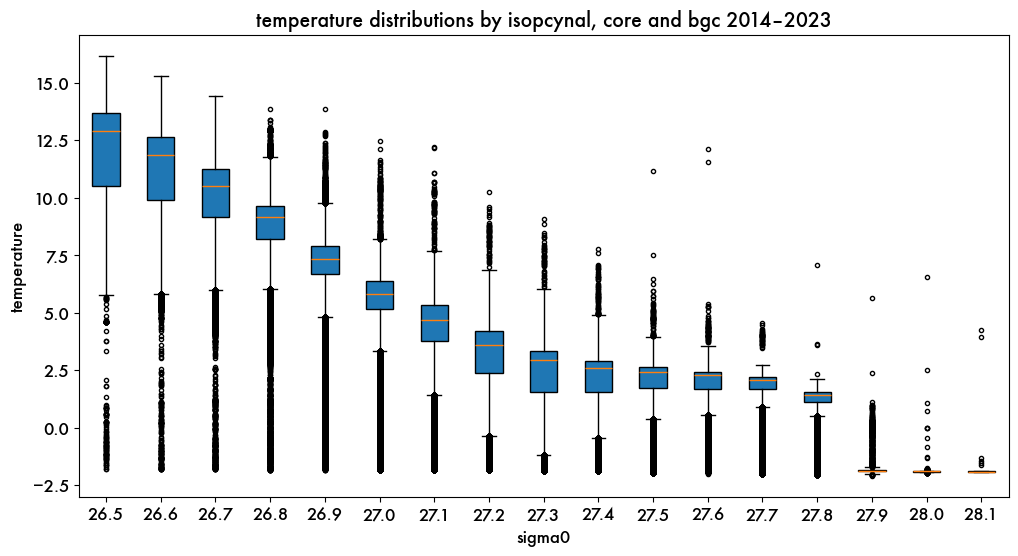

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

list = [x.CT for x in isodict.values()]

bplot = ax.boxplot(list, patch_artist=True, tick_labels = isodict.keys(), sym='.')

ax.set_ylabel('CT')
ax.set_xlabel('sigma0')
ax.set_title('CT distributions by isopcynal, core and bgc 2014–2023')

In [ ]:
temp

In [ ]:
print("Average pressures for sigma0 values (core and bgc floats)")
for k, v in isodict.items():
    print(k, '\t', v.pressure.mean())

Average pressures for sigma0 values (core and bgc floats)
26.5 	 149.2155480215807
26.6 	 183.51149927455327
26.7 	 219.58860156939426
26.8 	 301.6489350542902
26.9 	 406.71342644782425
27.0 	 504.98023242990956
27.1 	 568.0594192206254
27.2 	 554.6375169337014
27.3 	 524.1388743421224
27.4 	 512.0985162693661
27.5 	 496.1068239633108
27.6 	 501.70258049487524
27.7 	 522.1723660749927
27.8 	 577.7750014702091
27.9 	 248.75245098039215
28.0 	 377.0173657493989
28.1 	 731.6340836012862


In [ ]:
print("Number of data points for sigma0 values")
for k, v in isodict.items():
    print(k, '\t', v.pressure.count())

Number of data points for sigma0 values
26.5 	 266349
26.6 	 370806
26.7 	 546198
26.8 	 819854
26.9 	 898607
27.0 	 897733
27.1 	 796998
27.2 	 589062
27.3 	 458292
27.4 	 359971
27.5 	 332959
27.6 	 386360
27.7 	 488501
27.8 	 884228
27.9 	 3264
28.0 	 7486
28.1 	 1555


In [ ]:
sns.boxplot

{'whiskers': [<matplotlib.lines.Line2D at 0x470f87850>,
 'caps': [<matplotlib.lines.Line2D at 0x470f87be0>,
 'boxes': [<matplotlib.lines.Line2D at 0x470f875b0>],
 'medians': [<matplotlib.lines.Line2D at 0x470f93160>],
 'fliers': [<matplotlib.lines.Line2D at 0x470f93400>],
 'means': []}

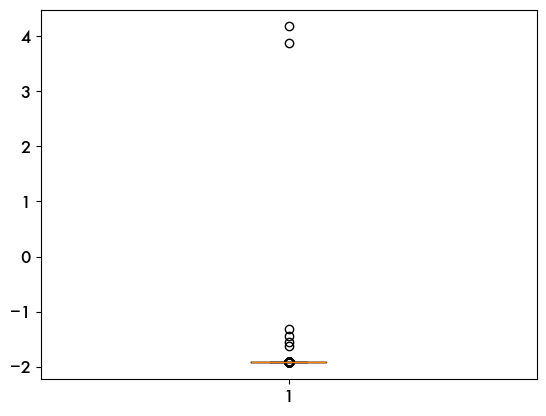

In [ ]:
sns.boxplot(isodict[28.1].CT)

(33.5, 35.0)

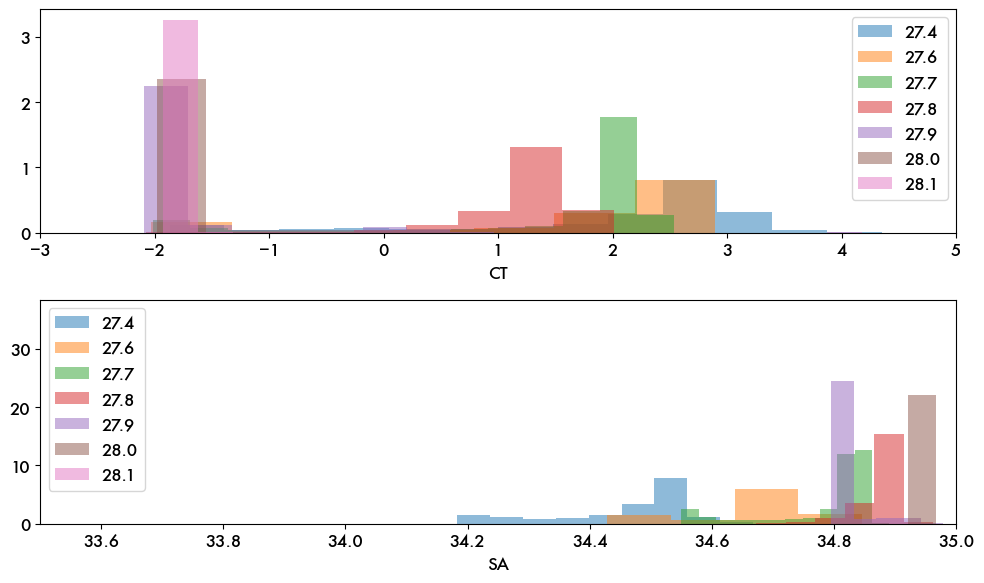

In [ ]:
fig = plt.figure(figsize=(10, 6), layout='tight')
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

# for k, group in isodict.items():
for sig in [27.4, 27.6, 27.7, 27.8, 27.9, 28.0, 28.1]:
    ax1.hist(isodict[sig].CT, bins=20, alpha=.5, label=sig, density=True)
    ax2.hist(isodict[sig].SA, bins=20, alpha=.5, label=sig, density=True)

for ax in [ax1,ax2]:
    ax.legend()

ax1.set_xlabel('CT')
ax2.set_xlabel('SA')

ax1.set_xlim([-3, 5])
ax2.set_xlim([33.5, 35])


In [ ]:
alldat

,profid,pressure,wmoid,latitude,longitude,datetime,yearday,CT,SA,sigma0,...,salinity_qc,pressure_qc,time_qc,position_qc,temp_error,psal_error,pres_error,pH,pH_qc,pH_error
5538312,5904184_id001,7.550000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062752,33.916040,27.101326,...,8,1,1,1,0.002,0.01,2.4,8.036440,1,0.015321
5538315,5904184_id001,11.730000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062162,33.915951,27.101285,...,8,1,1,1,0.002,0.01,2.4,8.037667,1,0.015321
5538319,5904184_id001,16.220001,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062796,33.915852,27.101172,...,8,1,1,1,0.002,0.01,2.4,8.038201,1,0.015321
5538322,5904184_id001,21.660000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.064599,33.915659,27.100925,...,8,1,1,1,0.002,0.01,2.4,8.038585,1,0.015321
5538326,5904184_id001,26.610000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.063223,33.915310,27.100716,...,8,1,1,1,0.002,0.01,2.4,8.039553,1,0.015321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336378,5904478_id001,19.440000,5904478,-64.998,0.004,2014-12-18 16:32:43.002000128,351.689387,-1.325542,33.783838,27.052838,...,1,1,1,8,0.002,0.01,2.4,8.059939,1,0.033806
6336379,5904478_id001,21.640001,5904478,-64.998,0.004,2014-12-18 16:32:43.002000128,351.689387,-1.304686,33.835160,27.093575,...,1,1,1,8,0.002,0.01,2.4,8.057148,1,0.033793
6336380,5904478_id001,23.540000,5904478,-64.998,0.004,2014-12-18 16:32:43.002000128,351.689387,-1.321835,33.882449,27.132280,...,1,1,1,8,0.002,0.01,2.4,8.056596,1,0.033794
6337797,5904478_id002,28.260000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-1.096631,33.790675,27.050690,...,1,1,1,1,0.002,0.01,2.4,8.109830,1,0.033722


In [ ]:
def list_profile_DFs(df):
    """ 
    @param df: dataframe with all profiles
    @return: list of dataframes, each with a unique profile
    """
    profids = pd.unique(df.profid)
    profile_DFs = []
    for i in range(len(profids)):
        profile_DFs.append(df[df['profid']==profids[i]].copy())
    return profile_DFs

In [ ]:

def get_isopycnal_signal(platDF, ave_isopycnal, var_thresh=0.01, var_list = ['yearday', 'pressure', 'sigma0', 'nitrate', 'spice']):
    """ 
    Originally from RandomForest_SG mod_DFproc.py

    @param: prof_list: list of glider DF's, using list_profile_DFs 
            ave_isopycnal: list of isopycnal values to find in each profile
            var_thresh: threshold for finding sigma in each profile
            var_list: which variables to keep track of
    @return: Dictionary object containing along-isopycnal variables. 
    """
    prof_list = list_profile_DFs(platDF)
    dLine = dict.fromkeys(ave_isopycnal)

    for sig in ave_isopycnal:
        temp = pd.DataFrame()

        for prof in prof_list:
            # Find all sigma points that are within that threshold
            rangeDF = pd.DataFrame() 
            rangeDF = prof[(prof['sigma0']< (sig+var_thresh)) & (prof['sigma0'] > (sig-var_thresh))].copy()

            # Choose mean of values
            rowdat = rangeDF[var_list].copy().dropna()
            rowdat = np.mean(rowdat, axis=0) #nanmean avoided if you drop nans above.
            temp = pd.concat([temp, rowdat], axis=1)
            
        temp = temp.T
        dLine[sig] = temp

    return dLine
